# 00 — Dataset Exploration

Quick look at the raw MELD CSVs: sizes, label distributions, text lengths, and missing values.
Nothing is modified here — this is purely observational.

> **Run this first** before any preprocessing notebook.

In [1]:
import os
import sys

# Make sure the project root (parent of notebooks/) is on the path so 'src' is importable.
_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.abspath(os.path.join(_here, '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

import pandas as pd
import matplotlib.pyplot as plt

from src.config import TRAIN_CSV, DEV_CSV, TEST_CSV, TEXT_COL, LABEL_COL, LABEL_REMAP

## Load raw splits

In [3]:
train_raw = pd.read_csv(TRAIN_CSV)
dev_raw   = pd.read_csv(DEV_CSV)
test_raw  = pd.read_csv(TEST_CSV)

print('Columns:', train_raw.columns.tolist())
print(f'Train: {len(train_raw):,} rows | Dev: {len(dev_raw):,} rows | Test: {len(test_raw):,} rows')

Columns: ['Sr No.', 'Utterance', 'Speaker', 'Emotion', 'Sentiment', 'Dialogue_ID', 'Utterance_ID', 'Season', 'Episode', 'StartTime', 'EndTime']
Train: 9,989 rows | Dev: 1,109 rows | Test: 2,610 rows


## Missing values

In [4]:
for name, df in [('train', train_raw), ('dev', dev_raw), ('test', test_raw)]:
    missing = df[[TEXT_COL, LABEL_COL]].isna().sum()
    print(f'[{name}] missing →', missing.to_dict())

[train] missing → {'Utterance': 0, 'Emotion': 0}
[dev] missing → {'Utterance': 0, 'Emotion': 0}
[test] missing → {'Utterance': 0, 'Emotion': 0}


## Label distribution

Note: MELD labels are lowercase; `joy` will be remapped to `happiness` later.

In [5]:
def label_counts(df, split_name):
    counts = (
        df[LABEL_COL].astype(str).str.lower().str.strip()
        .replace(LABEL_REMAP)
        .value_counts()
        .sort_index()
    )
    print(f'\n--- {split_name} ---')
    print(counts.to_string())
    return counts

train_counts = label_counts(train_raw, 'train')
dev_counts   = label_counts(dev_raw,   'dev')
test_counts  = label_counts(test_raw,  'test')


--- train ---
Emotion
anger        1109
disgust       271
fear          268
happiness    1743
neutral      4710
sadness       683
surprise     1205

--- dev ---
Emotion
anger        153
disgust       22
fear          40
happiness    163
neutral      470
sadness      111
surprise     150

--- test ---
Emotion
anger         345
disgust        68
fear           50
happiness     402
neutral      1256
sadness       208
surprise      281


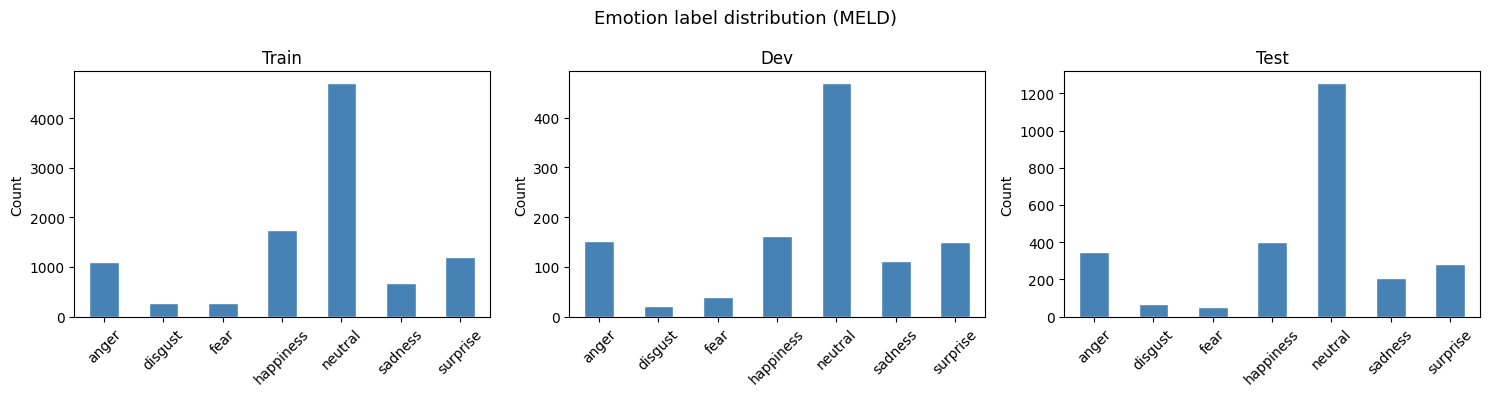

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (counts, title) in zip(axes, [
    (train_counts, 'Train'), (dev_counts, 'Dev'), (test_counts, 'Test')
]):
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Emotion label distribution (MELD)', fontsize=13)
plt.tight_layout()
plt.show()

## Text length distribution

Word count stats (train):
count    9989.0
mean        8.0
std         6.2
min         1.0
25%         3.0
50%         6.0
75%        11.0
max        69.0
Name: n_words, dtype: float64


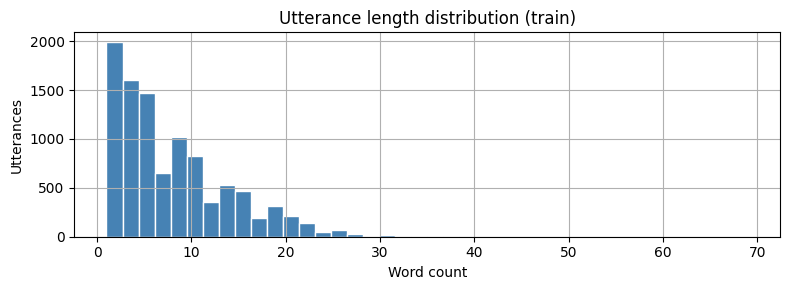

In [7]:
train_raw['n_words'] = train_raw[TEXT_COL].astype(str).str.split().str.len()

print('Word count stats (train):')
print(train_raw['n_words'].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 3))
train_raw['n_words'].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Word count')
ax.set_ylabel('Utterances')
ax.set_title('Utterance length distribution (train)')
plt.tight_layout()
plt.show()

## Sample utterances per emotion

In [8]:
sample_df = (
    train_raw[[TEXT_COL, LABEL_COL]].copy()
    .assign(**{LABEL_COL: lambda d: d[LABEL_COL].str.lower().str.strip().replace(LABEL_REMAP)})
    .dropna()
    .groupby(LABEL_COL)
    .apply(lambda g: g.sample(min(3, len(g)), random_state=42))
    .reset_index(drop=True)
)
pd.set_option('display.max_colwidth', 120)
sample_df

,Utterance
0,What?! What the hell?!
1,Because Im not going to spend one more day with someone whose out to sabotage my every move.
2,Come on apartment! Come on apartment! Oh! I know queen is high!
3,"The big deal is I dont want naked, greasy strangers in my apartment when I want to kick back with a puzzlebeer! Co..."
4,"That's fine, just don't bring it in my mouth."
5,Well you should be embarrassed.
6,"If we broke up, and I lost you..."
7,"Oh! Hey, Mr. Treeger."
8,I was scared of telling you.
9,Noooo! I'm lying. I am so drunk.


## Per-emotion statistics (combined train + dev + test)

For each emotion: share of total utterances, text length (word count) μ±σ / median, and audio clip duration μ±σ / median.

In [26]:
import numpy as np

MAX_AUDIO_DURATION_S = 10.0

# ── Parse SRT-style timestamps: 'HH:MM:SS,mmm' → seconds ───────────────────
def _srt_to_s(ts: str) -> float:
    h, m, rest = ts.split(':')
    s, ms = rest.split(',')
    return int(h) * 3600 + int(m) * 60 + int(s) + int(ms) / 1000

# ── Annotate each split with word count and clipped clip duration ────────────
def _annotate(df):
    df = df.copy()

    # Normalize labels, including joy -> happiness if LABEL_REMAP contains it.
    df[LABEL_COL] = (
        df[LABEL_COL].astype(str).str.lower().str.strip().replace(LABEL_REMAP)
    )

    # Text length measured as number of whitespace-separated words.
    df['_n_words'] = df[TEXT_COL].astype(str).str.split().str.len()

    # Raw duration from MELD timestamps.
    raw_duration = (
        df['EndTime'].apply(_srt_to_s) -
        df['StartTime'].apply(_srt_to_s)
    )

    # Effective duration used by the audio pipeline:
    # clips longer than 10 seconds are truncated.
    df['_duration_s'] = raw_duration.clip(lower=0.0, upper=MAX_AUDIO_DURATION_S)

    return df

_all = pd.concat(
    [_annotate(train_raw),
     _annotate(dev_raw),
     _annotate(test_raw)],
    ignore_index=True
)
_N = len(_all)

# ── Build the summary table ──────────────────────────────────────────────────
_rows = []
for emotion, grp in _all.groupby(LABEL_COL):
    n = len(grp)
    wc = grp['_n_words']
    dur = grp['_duration_s']

    _rows.append({
        'Emotion': emotion.capitalize(),
        'Utterances (%)': f"{n:,} ({100 * n / _N:.1f}%)",
        'Text length μ±σ / median':
            f"{wc.mean():.1f}±{wc.std():.1f} / {int(wc.median())}",
        'Audio duration μ±σ / median':
            f"{dur.mean():.2f}±{dur.std():.2f} / {dur.median():.2f} s",
    })

_stats = (
    pd.DataFrame(_rows)
    .set_index('Emotion')
    .rename_axis(None)
)

print(
    f'Total utterances: {_N:,}  '
    f'(train {len(train_raw):,} | dev {len(dev_raw):,} | test {len(test_raw):,})'
)
_stats

Total utterances: 13,708  (train 9,989 | dev 1,109 | test 2,610)


,Utterances (%),Text length μ±σ / median,Audio duration μ±σ / median
Anger,"1,607 (11.7%)",9.2±6.5 / 8,3.28±2.16 / 2.75 s
Disgust,361 (2.6%),10.0±6.9 / 8,3.69±2.32 / 3.05 s
Fear,358 (2.6%),9.3±6.3 / 8,3.26±2.16 / 2.63 s
Happiness,"2,308 (16.8%)",7.7±6.0 / 6,3.16±2.29 / 2.50 s
Neutral,"6,436 (47.0%)",7.8±6.2 / 6,2.97±2.11 / 2.38 s
Sadness,"1,002 (7.3%)",10.0±7.0 / 9,3.71±2.41 / 2.96 s
Surprise,"1,636 (11.9%)",6.0±5.0 / 5,2.67±2.04 / 2.05 s


In [24]:
disgust = _all[_all[LABEL_COL] == "disgust"]

disgust["_duration_s"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    361.000000
mean       4.404917
std       12.461304
min        0.275000
50%        3.045000
75%        5.088000
90%        6.923000
95%        8.540000
99%       12.928400
max      235.068000
Name: _duration_s, dtype: float64

In [25]:
disgust.sort_values("_duration_s", ascending=False)[
    ["Dialogue_ID", "Utterance_ID", TEXT_COL, "_duration_s"]
].head(10)

,Dialogue_ID,Utterance_ID,Utterance,_duration_s
13150,220,0,Whats that smell?,235.068
3279,344,15,"Tell me about it, huh? Oh no-no-no, I'm not with her, she's just Monica! Ewwuck!",22.939
1422,153,8,"Oh, well dont take it to the same place you took the stereo, cause theyve had that thing for over a week.",15.682
9338,976,9,"Rachel, it's not that your friend is bad, it's that she's so bad, she makes me want to put my finger through my eye ...",13.178
7572,804,6,": Cause youre a little princess! ""Daddy, buy me a pizza. Daddy, buy me a candy factory. Daddy, make the cast of",12.762
3602,383,1,"I saw this movie once where there was a door and no one knew what was behind it, and when they finally got it open m...",12.680
4245,455,17,Bye. What a manipulative bitch.,11.803
11382,30,5,"You know what, where he hugs you and kinda rolls you away and... Oh... my....God.",11.386
1188,127,4,"Youre going to a clinic, and a pyjama store!",11.094
1041,111,17,"Young! Youre a man-child okay?! Now go get changed because everybodys ready and please, oh please, keep my underwear!",11.093
